# SOTU Speech Analytics: Rhetoric Measurement Framework

This notebook demonstrates a reproducible workflow for analyzing State of the Union speeches across multiple years.

Rather than treating the speeches as text to summarize, the goal is to treat them as a measurable corpus. The workflow compares speeches on agenda structure, rhetorical moves, framing, coalition targeting, and topic-level patterns.

The demo uses cleaned and chunked SOTU transcripts, topic assignments, LLM-assisted rhetoric labels, and derived metrics to explore how presidential messaging changes across years.

## Why this matters

Simple keyword counts can show which words appear most often, but they miss the structure of the argument.

This workflow asks richer questions:

- Which topics dominate each speech?
- Which rhetorical moves are used most often?
- How do tone and framing vary by topic?
- Which constituencies or coalitions are addressed?
- How do these patterns change across years?

The emphasis is on building a repeatable measurement framework, not on treating the LLM as an oracle.

## Analysis plan

The workflow is organized around a few reusable stages:

1. Load cleaned speech chunks and derived topic labels.
2. Join topic assignments with LLM-assisted rhetoric labels.
3. Validate and patch missing labels where needed.
4. Map granular topics into higher-level macro topics.
5. Compare rhetorical devices, tones, and topic patterns across years.
6. Generate tables and visualizations that make the differences easier to inspect.

The supporting source code lives under:

- `src/demos/sotu-speech-analytics`
- `assets/sotu-speech-analytics`

This notebook is intended as a portfolio-facing overview of the analysis workflow.


In [8]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import sys
from pathlib import Path


def find_repo_root(start: Path = Path.cwd()) -> Path:
    current = start.resolve()
    for path in [current, *current.parents]:
        if (path / ".git").exists():
            return path
    raise RuntimeError("Could not find repo root")

REPO_ROOT = find_repo_root()
BASE = REPO_ROOT / "assets" / "sotu-speech-analytics" / "data"

PATH_TOPICS = BASE / "derived" / "topics_global" / "global_chunk_topics.jsonl"
PATH_TOPIC_LABELS = BASE / "derived" / "topics_global" / "global_topic_labels_llm.json"
PATH_TOPIC_MACRO_MAP = BASE / "derived" / "topics_global" / "global_topic_macro_map.json"
PATH_RHET = BASE / "derived" / "rhetoric" / "global_chunk_rhetoric.jsonl"

sys.path.insert(0, str(REPO_ROOT / "src"))

def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

topics = pd.DataFrame(read_jsonl(PATH_TOPICS))
rhet = pd.DataFrame(read_jsonl(PATH_RHET))


# Treat empty strings as NaN
rhet["error"] = rhet["error"].replace("", np.nan)

# Define "good" rows
rhet["is_good"] = rhet["tone"].notna() & rhet["device"].notna() & rhet["target"].notna() & rhet["error"].isna()

# Confidence ranking
conf_rank = {"low": 0, "med": 1, "high": 2}
rhet["conf_rank"] = rhet["confidence"].map(conf_rank).fillna(-1)

# Sort so best rows come first, then drop duplicates on chunk_id
rhet_sorted = rhet.sort_values(
    by=["is_good", "conf_rank"],
    ascending=[False, False],
)

rhet_dedup = rhet_sorted.drop_duplicates(subset=["chunk_id"], keep="first").drop(columns=["is_good", "conf_rank"])

# Now merge using the deduped rhetoric
df = topics.merge(
    rhet_dedup,
    on=["chunk_id"],  # chunk_id is unique; year/index/topic are already in topics
    how="left",
    suffixes=("", "_r")
)



In [2]:
import json
from pathlib import Path
import pandas as pd

# Load global topic labels (LLM)
topic_labels_raw = json.loads(PATH_TOPIC_LABELS.read_text(encoding="utf-8"))

topic_label_map = {}
for k, v in topic_labels_raw.items():
    try:
        tid = int(k)
    except Exception:
        tid = int(v.get("topic_id", k))
    # v might be a dict with "label"
    topic_label_map[tid] = (v.get("label") if isinstance(v, dict) else str(v)).title()

# Canonicalize df fields: keep left-side (topics) values
df = df.copy()
df["topic_label"] = df["topic_id"].map(topic_label_map)

# Drop the redundant rhs cols
df = df.drop(columns=["year_r", "chunk_index_r", "topic_id_r", "uses_guest_example_r", "guest_count_r"])

print("Rows:", len(df))
print("Missing rhetoric labels:", df["tone"].isna().sum())
df.head(3)


Rows: 2027
Missing rhetoric labels: 51


,year,chunk_id,chunk_index,uses_guest_example,guest_count,topic_id,tone,device,target,confidence,evidence,model,n_clauses,device_mix,tone_mix,error,topic_label
0,2010,2010_0000,0,False,0,0,unifying,values,the_public,high,{'device': 'Our Constitution declares that fro...,mistral:latest,1,{'values': 1},{'unifying': 1},NaN,Military Appreciation
1,2010,2010_0001,1,False,0,22,grave,values,the_public,high,{'device': 'assume that our progress was inevi...,mistral:latest,1,{'values': 1},{'grave': 1},NaN,National Optimism
2,2010,2010_0002,2,False,0,22,grave,values,the_public,high,{'device': 'These were the times that tested t...,mistral:latest,1,{'values': 1},{'grave': 1},NaN,National Optimism


In [3]:
missing = df[df["tone"].isna()][["year","chunk_id","chunk_index","topic_id","topic_label"]].copy()
missing.shape, missing.head()


((51, 5),
      year   chunk_id  chunk_index  topic_id                     topic_label
 71   2010  2010_0071           71        29                     Budget Cuts
 89   2010  2010_0089           89        11  Higher Education Affordability
 99   2010  2010_0099           99         8              Health Care Reform
 322  2012  2012_0110          110        26                    Clean Energy
 326  2012  2012_0114          114        26                    Clean Energy)

In [4]:
ALLOWED_DEVICES = {"policy_ask","credit_claim","attack","exemplar","values","threat"}
ALLOWED_TONES = {"neutral","unifying","adversarial","upbeat","grave","urgent"}
ALLOWED_TARGETS = {"the_public","institution","special_guests","domestic_opponents","foreign_adversaries","allies","unspecified"}

def validate_pred(p):
    if not p: 
        return None
    d = p.get("device")
    t = p.get("tone")
    g = p.get("target")
    if d not in ALLOWED_DEVICES: 
        return None
    if t not in ALLOWED_TONES:
        return None
    if g not in ALLOWED_TARGETS:
        return None
    return p


In [5]:
from genai_demos.sotu_speech_analytics.sotu_analytics.prompts import build_rhetoric_prompt
from genai_demos.sotu_speech_analytics.sotu_analytics.models.topic_label_llm import ollama_generate_json

# Load chunk text index
def read_jsonl(path: Path):
    out = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if line.strip():
            out.append(json.loads(line))
    return out

def safe_ollama_json(model, prompt, timeout=180, num_predict=160, retries=1):
    last_err = None
    for _ in range(retries + 1):
        try:
            return ollama_generate_json(model, prompt, temperature=0.0, timeout=timeout, num_predict=num_predict)
        except (json.JSONDecodeError, ValueError) as e:
            last_err = e
            prompt = prompt + "\n\nREMINDER: Return ONE JSON object only. No double quotes inside evidence strings.\n"
    return {}


chunk_text = {}
for y in sorted(df["year"].unique()):
    rows = read_jsonl(BASE / "chunks" / f"{y}.jsonl")
    for r in rows:
        chunk_text[r["chunk_id"]] = r["text"]

patch_rows = []
model = "qwen2.5:14b-instruct-q4_K_M"

for _, row in missing.iterrows():
    year = int(row["year"])
    cid = row["chunk_id"]
    prompt = build_rhetoric_prompt(year, chunk_text[cid])
    resp = validate_pred(safe_ollama_json(model, prompt, timeout=180, num_predict=160, retries=1))
    if resp:
        patch_rows.append({
            "year": year,
            "chunk_id": cid,
            "tone": resp.get("tone"),
            "device": resp.get("device"),
            "target": resp.get("target"),
            "uses_guest_example": resp.get("uses_guest_example"),
            "confidence": resp.get("confidence"),
            "evidence": resp.get("evidence", {}),
            "model": model,
        })

patch = pd.DataFrame(patch_rows)
patch.head(), patch["tone"].isna().sum()


(   year   chunk_id         tone      device       target  uses_guest_example  \
 0  2010  2010_0071        grave      threat   the_public               False   
 1  2010  2010_0089       upbeat  policy_ask   the_public               False   
 2  2010  2010_0099       upbeat  policy_ask   the_public               False   
 3  2012  2012_0110  adversarial  policy_ask  institution               False   
 4  2012  2012_0114       upbeat  policy_ask  institution               False   
 
   confidence                                           evidence  \
 0       high  {'device': 'We need to make sure consumers and...   
 1       high  {'device': 'I urge the Senate to follow the Ho...   
 2       high  {'device': 'give small businesses and uninsure...   
 3       high  {'device': 'Congress shouldn’t at least set a ...   
 4       high  {'device': 'Send me a bill that creates these ...   
 
                          model  
 0  qwen2.5:14b-instruct-q4_K_M  
 1  qwen2.5:14b-instruct-q4_K_M  


In [6]:
df2 = df.merge(patch, on=["year","chunk_id"], how="left", suffixes=("", "_patch"))

for col in ["tone","device","target","uses_guest_example","confidence","evidence","model"]:
    df2[col] = df2[col].fillna(df2[f"{col}_patch"])

df2 = df2.drop(columns=[c for c in df2.columns if c.endswith("_patch")])

print("Missing after patch:", df2["tone"].isna().sum())


Missing after patch: 3


In [ ]:
macro_raw = json.loads(PATH_TOPIC_MACRO_MAP.read_text(encoding="utf-8"))

macro_topic_map = {int(k): v.get("macro_topic") for k, v in macro_raw.items()}
subtopic_map = {int(k): v.get("subtopic") for k, v in macro_raw.items()}
macro_conf_map = {int(k): v.get("confidence") for k, v in macro_raw.items()}

df2["macro_topic"] = df2["topic_id"].map(macro_topic_map)
df2["subtopic"] = df2["topic_id"].map(subtopic_map)
df2["macro_confidence"] = df2["topic_id"].map(macro_conf_map)

print("Missing macro_topic:", df2["macro_topic"].isna().sum())
#df2[["year","topic_id","topic_label","macro_topic","subtopic","macro_confidence","tone","device"]].head(10)
df2.groupby(by=["macro_topic","topic_label","subtopic"]).count()[['year']].reset_index().sort_values(by=["macro_topic","year"], ascending=[True, False])


Missing macro_topic: 0


,macro_topic,topic_label,subtopic,year
0,Crime and Public Safety,Law Enforcement Reform,Law Enforcement Reform,39
3,Economy and Jobs,Income Inequality,Income Inequality,92
4,Economy and Jobs,Job Creation,Job Creation,92
1,Economy and Jobs,American Jobs,American Jobs,74
2,Economy and Jobs,American Rescue Plan,American Rescue Plan,64
5,Education and Workforce,Higher Education Affordability,Higher Education Affordability,76
6,Foreign Policy and Alliances,Global Leadership,Global Leadership,62
10,Foreign Policy and Alliances,Ukraine Support,Ukraine Support,50
7,Foreign Policy and Alliances,Iran Nuclear Program,Iran nuclear program,41
8,Foreign Policy and Alliances,Middle East Conflict,Middle East Conflict,26


In [10]:
df2.groupby(by=["macro_topic"]).count()[['year']].reset_index().sort_values(by="year", ascending=False).rename(columns={"year": "count"})

,macro_topic,count
1,Economy and Jobs,322
9,National Security and Military,304
4,Governance and Institutions,213
8,National Identity and Values,207
3,Foreign Policy and Alliances,197
11,"Taxes, Budget, and Debt",184
10,Rights and Social Issues,181
5,Healthcare,171
2,Education and Workforce,76
6,Immigration and Border,67


In [15]:
import pandas as pd
pd.options.display.max_colwidth = 750

# df should already contain chunk_id + subtopic
target_subtopic = "American Jobs"

hits = df2[df2["subtopic"].fillna("").str.lower().eq(target_subtopic.lower())].copy()
print("Rows:", len(hits), "Years:", sorted(hits["year"].unique()))

# Load chunk text for only the years we need
chunk_text_by_id = {}
for y in sorted(hits["year"].unique()):
    p = BASE / "chunks" / f"{int(y)}.jsonl"
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            chunk_text_by_id[obj["chunk_id"]] = obj.get("text", "")

hits["text"] = hits["chunk_id"].map(chunk_text_by_id)

# Inspect: sorted by year, then chunk_index
cols = ["year","chunk_id","chunk_index","macro_topic","subtopic","topic_label","tone","device","target","text"]
cols = ["year","chunk_id","topic_id", "macro_topic","subtopic","tone","device","text"]
hits.sort_values(["year","chunk_index"])[cols].head(30)


Rows: 74 Years: [np.int64(2010), np.int64(2012), np.int64(2014), np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2022), np.int64(2024), np.int64(2026)]


,year,chunk_id,topic_id,macro_topic,subtopic,tone,device,text
52,2010,2010_0052,10,Economy and Jobs,American Jobs,upbeat,policy_ask,"While we're at it, let's also eliminate all capital gains taxes on small-business investment and provide a tax incentive for all large businesses and all small businesses to invest in new plants and equipment. Next, we can put Americans to work today building the infrastructure of tomorrow. From the first railroads to the Interstate Highway System, our Nation has always been built to compete."
53,2010,2010_0053,10,Economy and Jobs,American Jobs,upbeat,credit_claim,"From the first railroads to the Interstate Highway System, our Nation has always been built to compete. There's no reason Europe or China should have the fastest trains or the new factories that manufacture clean energy products. Tomorrow I'll visit Tampa, Florida, where workers will soon break ground on a new high-speed railroad funded by the Recovery Act."
54,2010,2010_0054,10,Economy and Jobs,American Jobs,upbeat,credit_claim,"Tomorrow I'll visit Tampa, Florida, where workers will soon break ground on a new high-speed railroad funded by the Recovery Act. There are projects like that all across this country that will create jobs and help move our Nation's goods, services, and information. We should put more Americans to work building clean energy facilities and give rebates to Americans who make their homes more energy efficient, which supports clean energy jobs."
55,2010,2010_0055,10,Economy and Jobs,American Jobs,urgent,policy_ask,"We should put more Americans to work building clean energy facilities and give rebates to Americans who make their homes more energy efficient, which supports clean energy jobs. And to encourage these and other businesses to stay within our borders, it is time to finally slash the tax breaks for companies that ship our jobs overseas and give those tax breaks to companies that create jobs right here in the United States of America. Now, the House has passed a jobs bill that includes some of these steps."
82,2010,2010_0082,10,Economy and Jobs,American Jobs,upbeat,policy_ask,"Third, we need to export more of our goods, because the more products we make and sell to other countries, the more jobs we support right here in America. So tonight we set a new goal: We will double our exports over the next 5 years, an increase that will support 2 million jobs in America. To help meet this goal, we're launching a National Export Initiative that will help farmers and small businesses increase their exports and reform export controls consistent with national security."
83,2010,2010_0083,10,Economy and Jobs,American Jobs,urgent,policy_ask,"To help meet this goal, we're launching a National Export Initiative that will help farmers and small businesses increase their exports and reform export controls consistent with national security. We have to seek new markets aggressively, just as our competitors are. If America sits on the sidelines while other nations sign trade deals, we will lose the chance to create jobs on our shores."
84,2010,2010_0084,10,Economy and Jobs,American Jobs,urgent,policy_ask,"If America sits on the sidelines while other nations sign trade deals, we will lose the chance to create jobs on our shores. But realizing those benefits also means enforcing those agreements so our trading partners play by the rules. And that's why we'll continue to shape a Doha trade agreement that opens global markets and why we will strengthen our trade relations in Asia and with key partners like South Korea and Panama and Colombia."
85,2010,2010_0085,10,Economy and Jobs,American Jobs,unifying,policy_ask,"And that's why we'll continue to shape a Doha trade agreement that opens global markets and why we will strengthen our trade relations in Asia and with key partners like South Korea and Panama and Colombia. Fourth, we need to invest in the skills and education of our people. Now, this year, we've broken through the stalem

In [16]:
def top_tone_topics(data, year: int, tone: str, top_n=8, min_chunks=10):
    sub = data[(data["year"] == year) & data["tone"].notna()].copy()
    grp = sub.groupby("topic_label")["tone"].agg(
        total="count",
        tone_count=lambda s: (s == tone).sum()
    )
    grp = grp[grp["total"] >= min_chunks].copy()
    grp["pct"] = (grp["tone_count"] / grp["total"] * 100).round(1)
    return grp.sort_values("pct", ascending=False).head(top_n)

for y in sorted(df2["year"].unique()):
    print(f"\n{y} - most adversarial topics")
    display(top_tone_topics(df2, y, "adversarial", top_n=10, min_chunks=10))
    print(f"\n{y} - most unifying topics")
    display(top_tone_topics(df2, y, "unifying", top_n=10, min_chunks=10))



2010 - most adversarial topics


,total,tone_count,pct
topic_label,,,
Earmark Reform,23,4,17.4
Democratic Process,19,3,15.8
American Rescue Plan,15,1,6.7
Budget Cuts,33,2,6.1
Health Care Reform,13,0,0.0
Job Creation,12,0,0.0
National Optimism,18,0,0.0



2010 - most unifying topics


,total,tone_count,pct
topic_label,,,
National Optimism,18,15,83.3
Democratic Process,19,7,36.8
Earmark Reform,23,7,30.4
Job Creation,12,3,25.0
Budget Cuts,33,5,15.2
American Rescue Plan,15,2,13.3
Health Care Reform,13,0,0.0



2012 - most adversarial topics


...

,total,tone_count,pct
topic_label,,,
National Optimism,17,13,76.5
National Security,12,7,58.3
National Pride,16,8,50.0
Fundamental Rights,24,7,29.2
Policy Implementation,17,4,23.5
Income Inequality,13,3,23.1
Health Care Reform,10,2,20.0
Earmark Reform,11,2,18.2
Job Creation,13,2,15.4



2026 - most adversarial topics


,total,tone_count,pct
topic_label,,,
Immigration Reform,16,10,62.5
American Rescue Plan,19,10,52.6
Democratic Process,10,5,50.0
Earmark Reform,14,6,42.9
Policy Implementation,31,8,25.8
National Security,15,2,13.3
Political Oppression,10,1,10.0
National Optimism,15,1,6.7
Reproductive Rights,34,1,2.9



2026 - most unifying topics


,total,tone_count,pct
topic_label,,,
National Pride,16,8,50.0
Military Sacrifice,12,4,33.3
Military Appreciation,30,9,30.0
Reproductive Rights,34,10,29.4
National Optimism,15,4,26.7
National Security,15,3,20.0
Veteran Support,10,2,20.0
Military Valor,25,3,12.0
Democratic Process,10,1,10.0


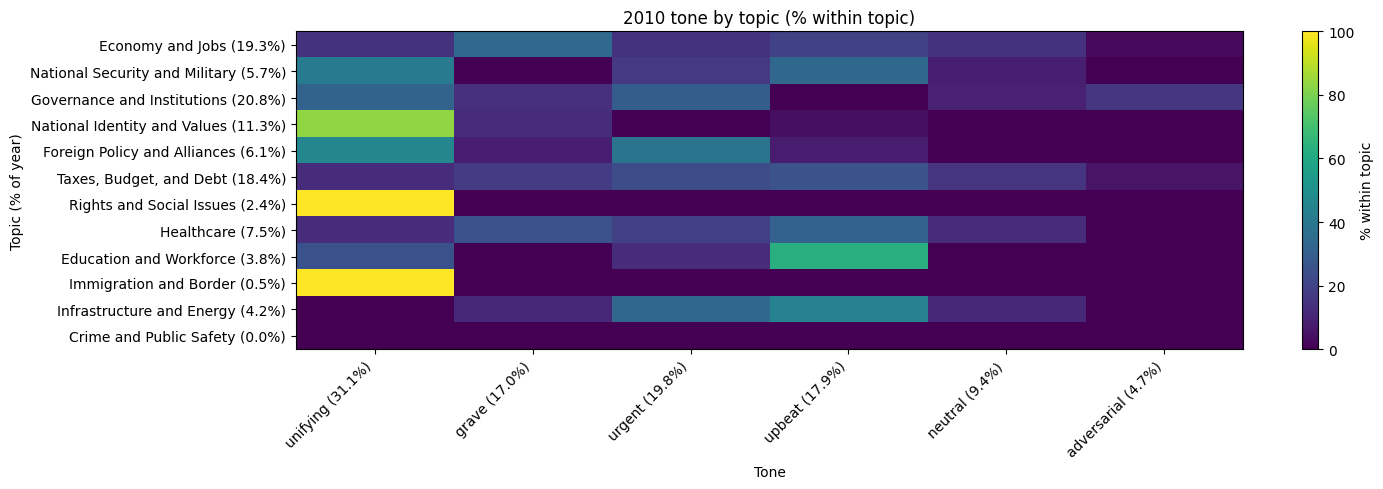

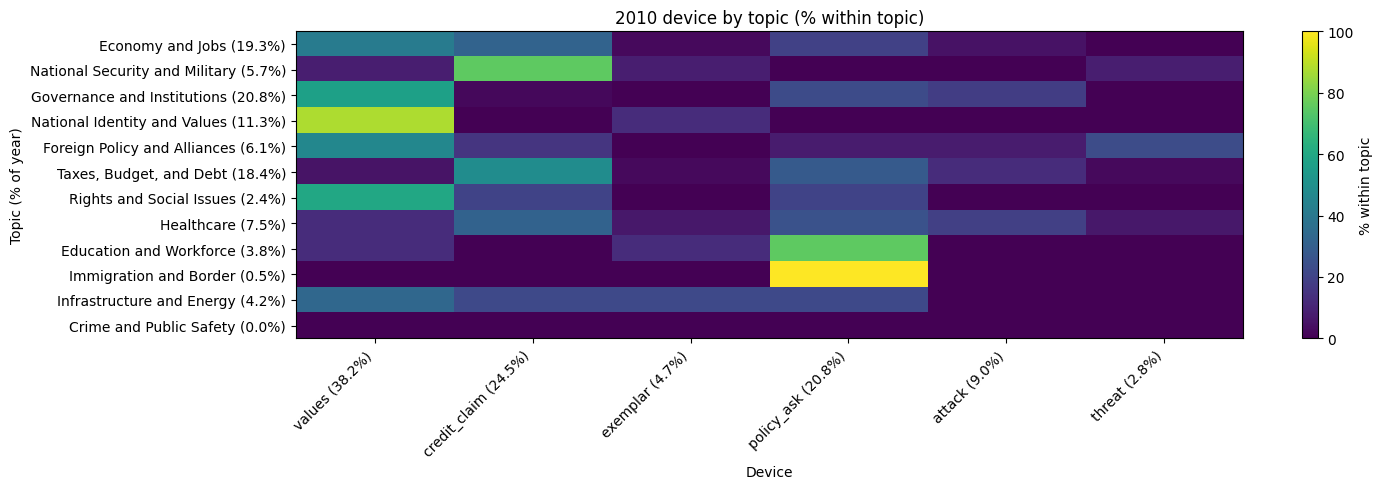

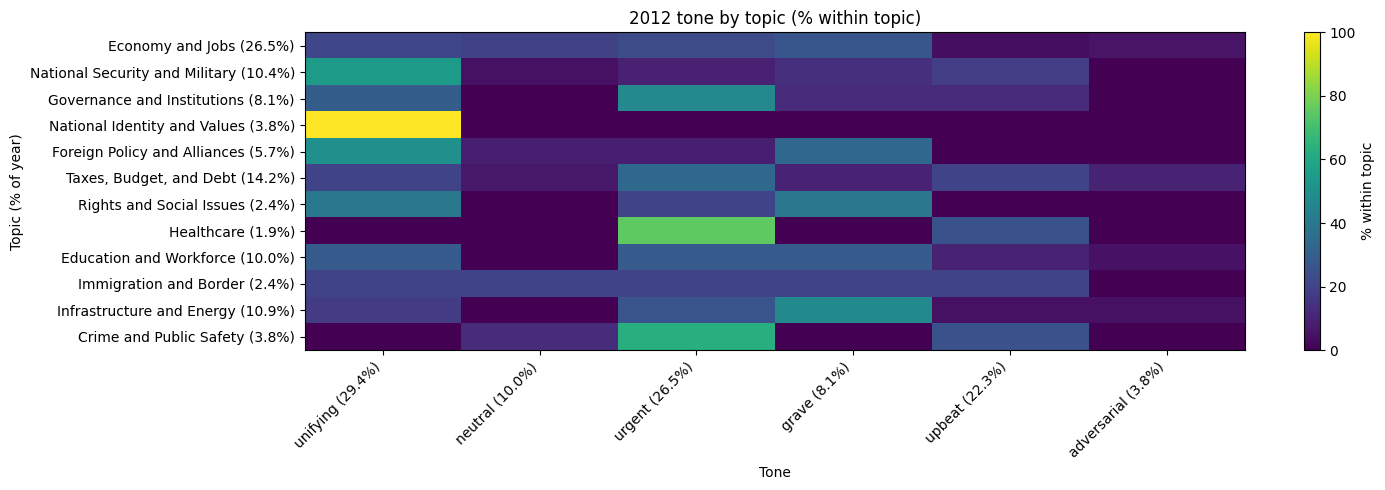

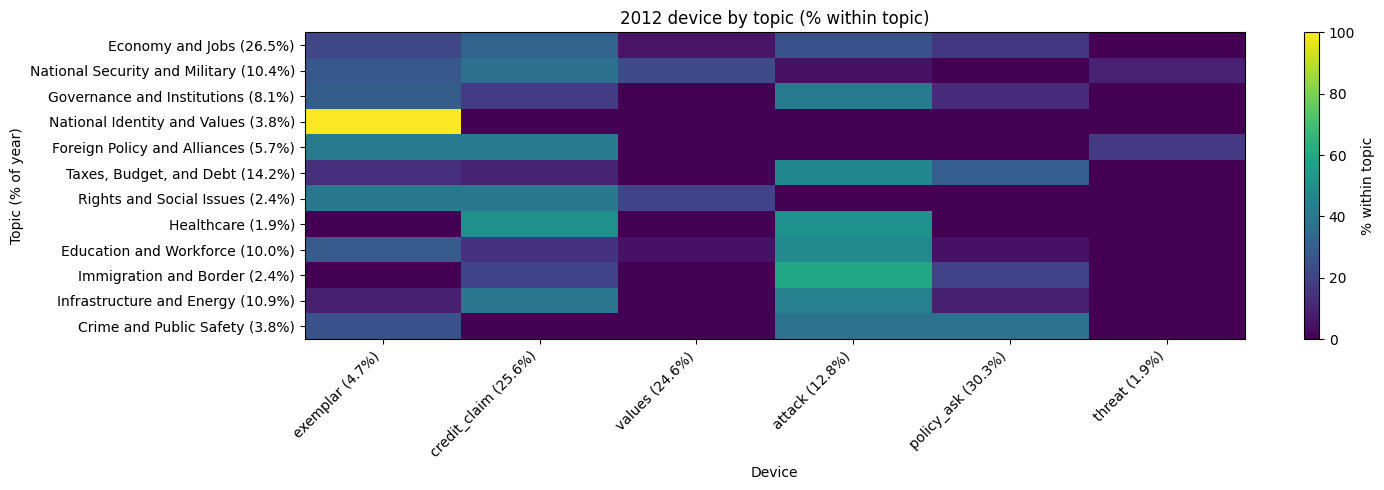

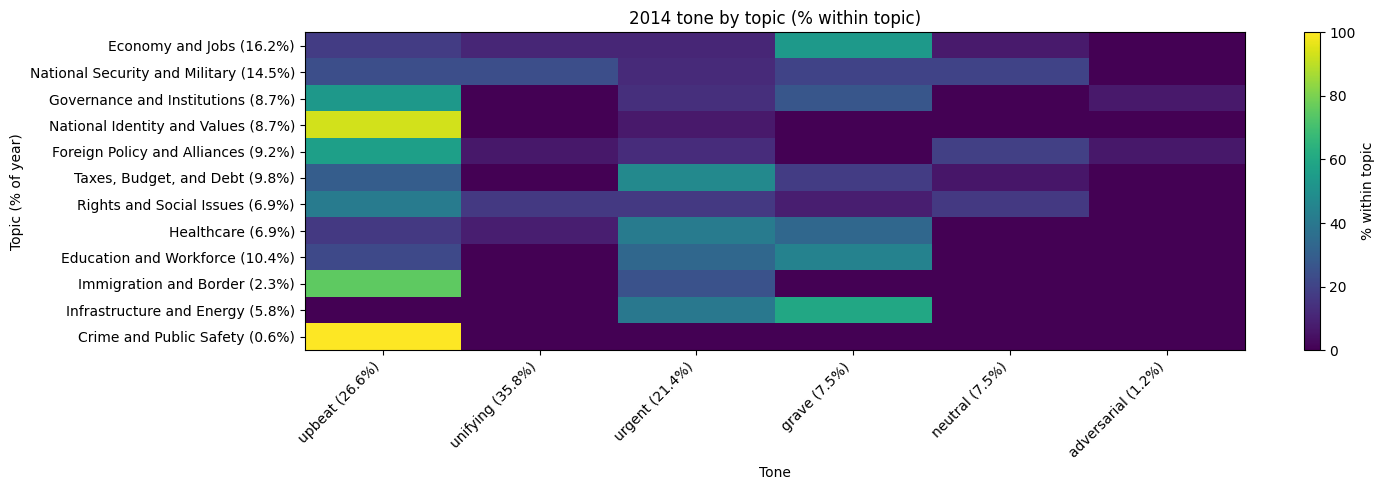

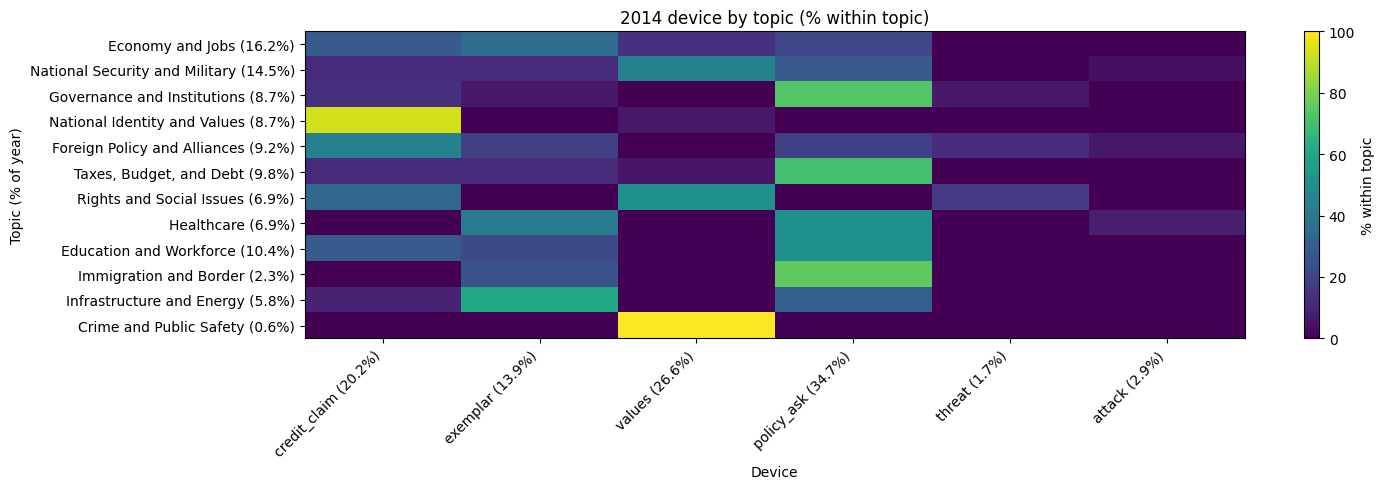

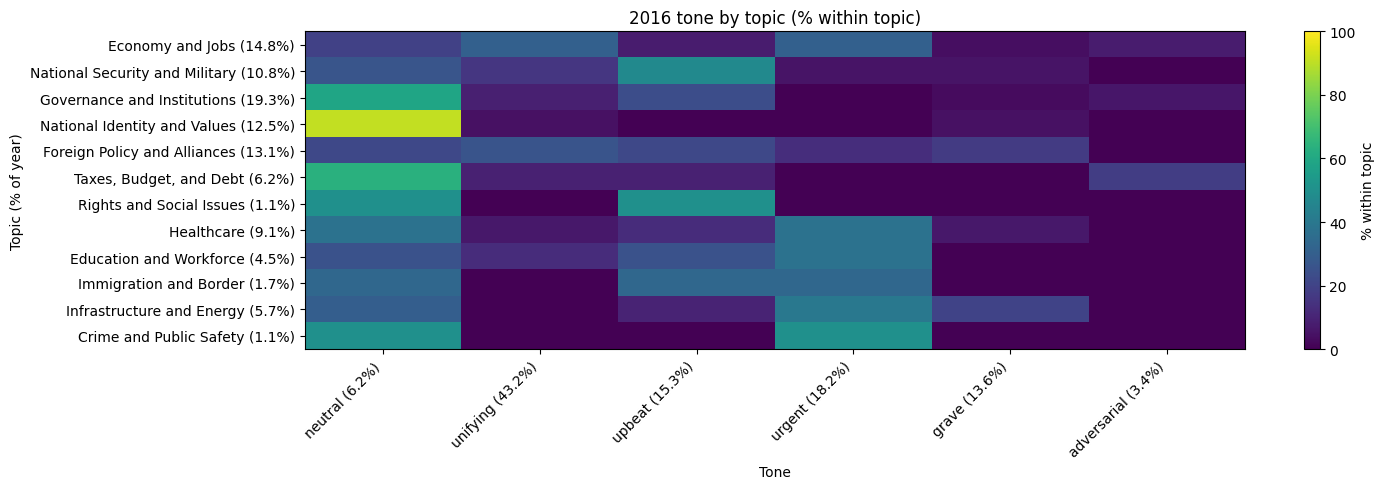

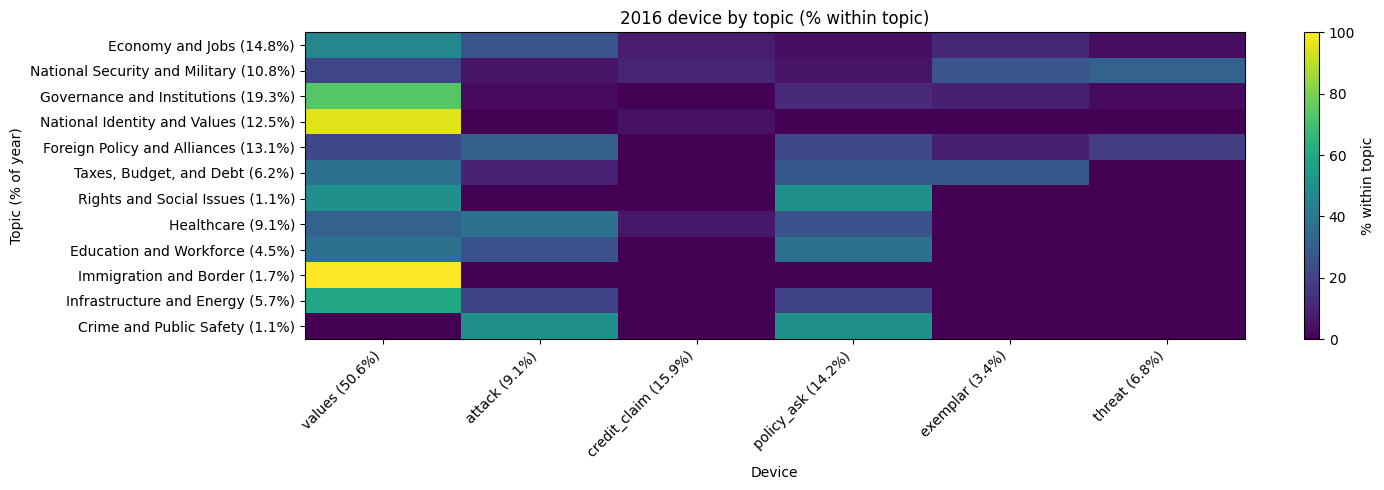

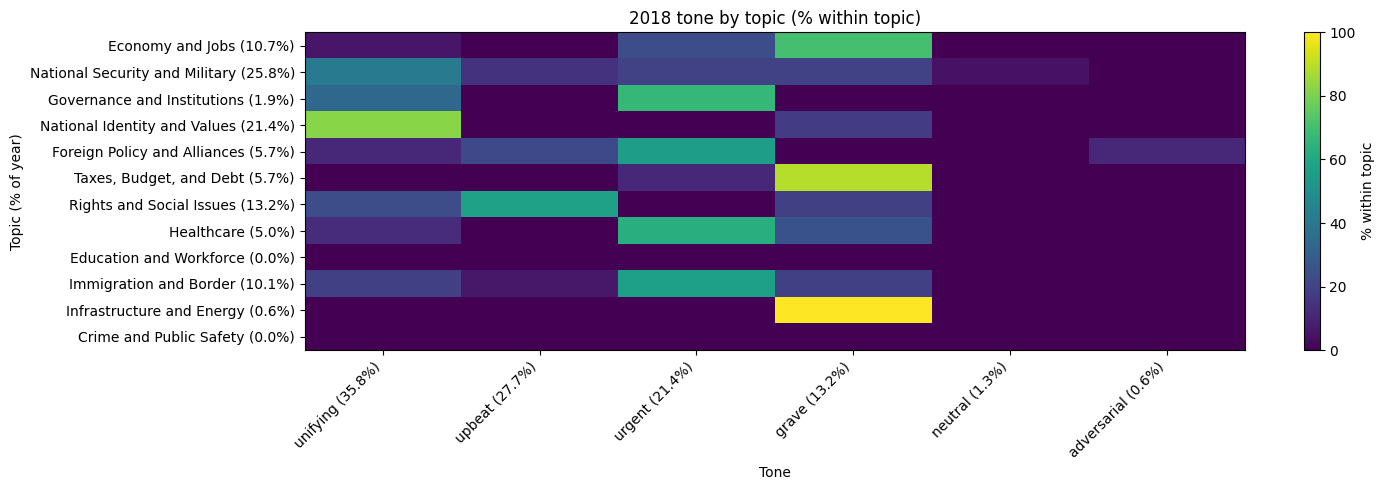

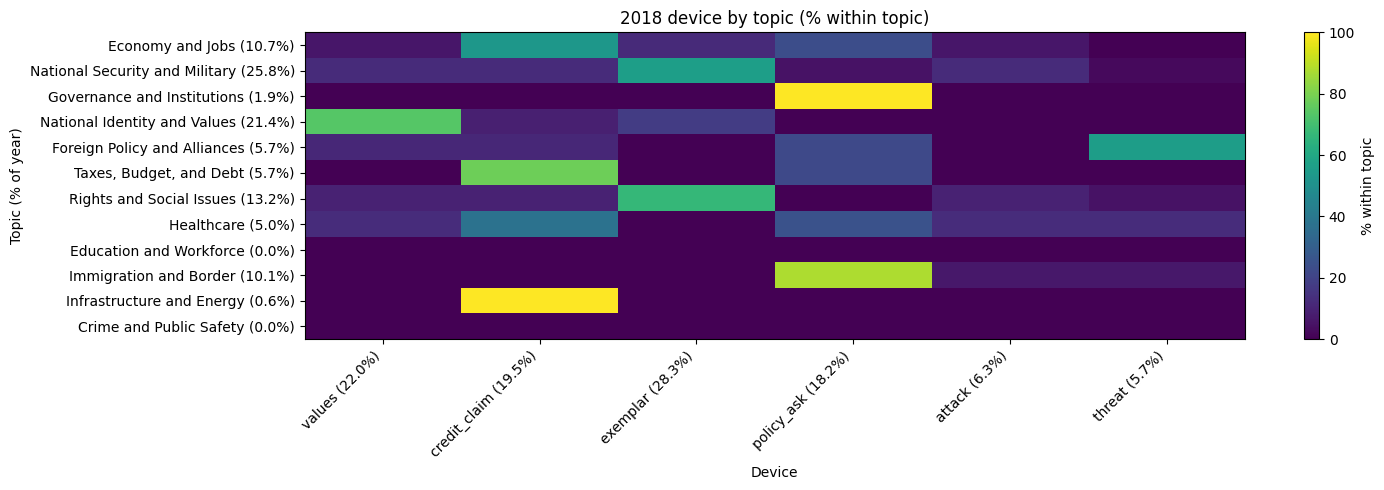

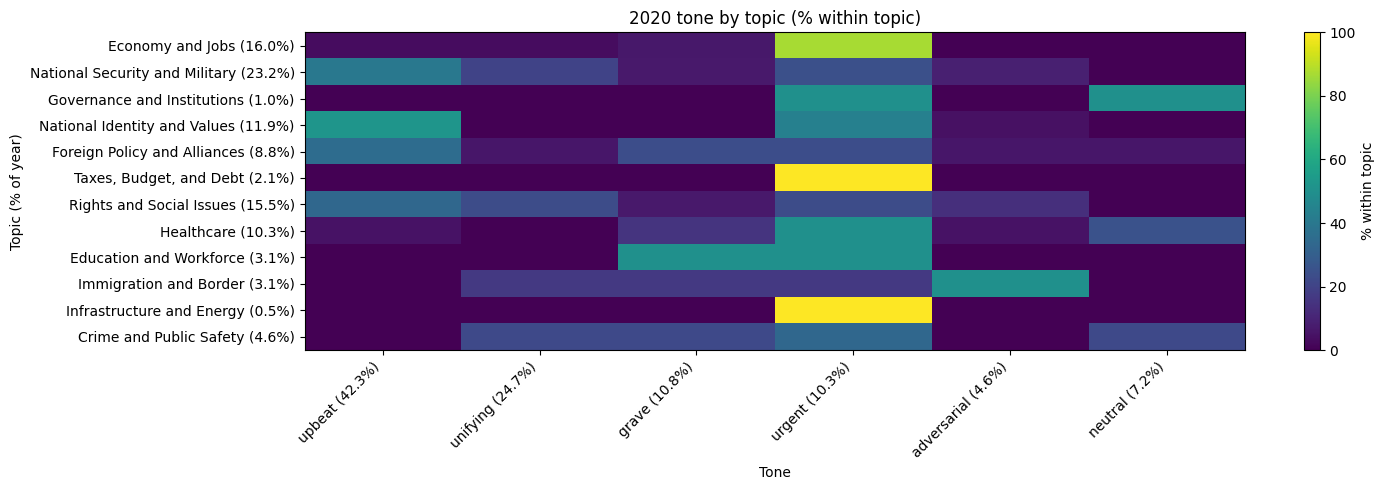

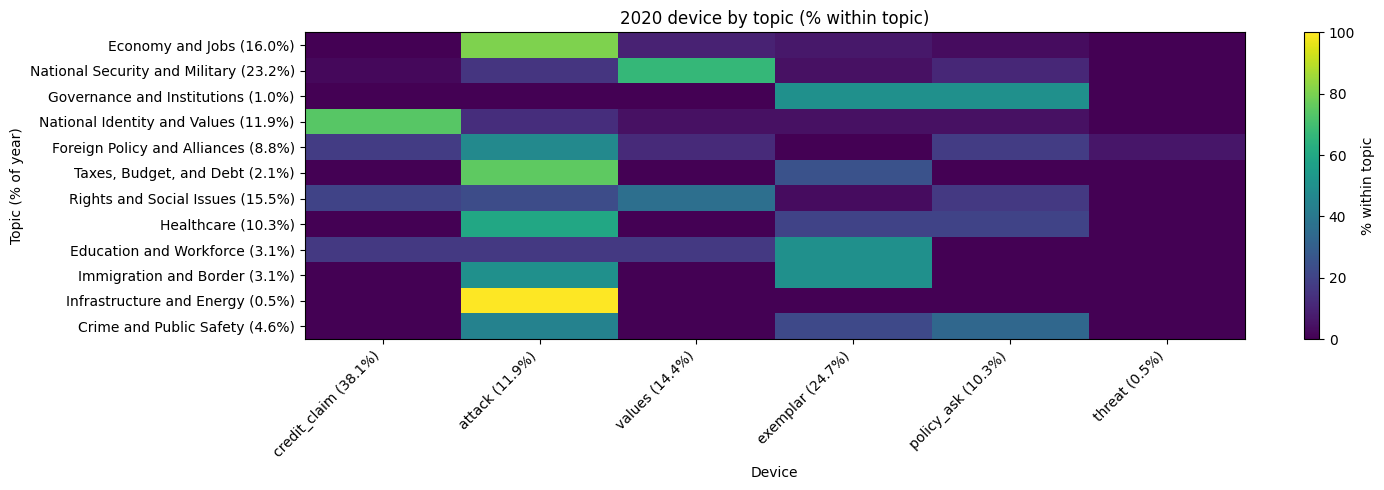

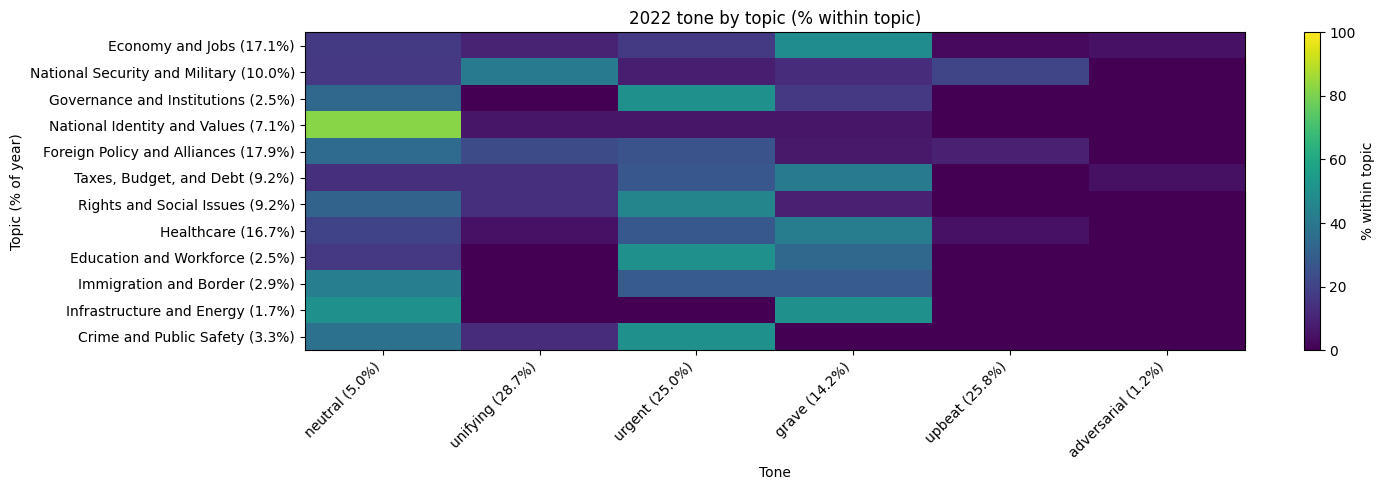

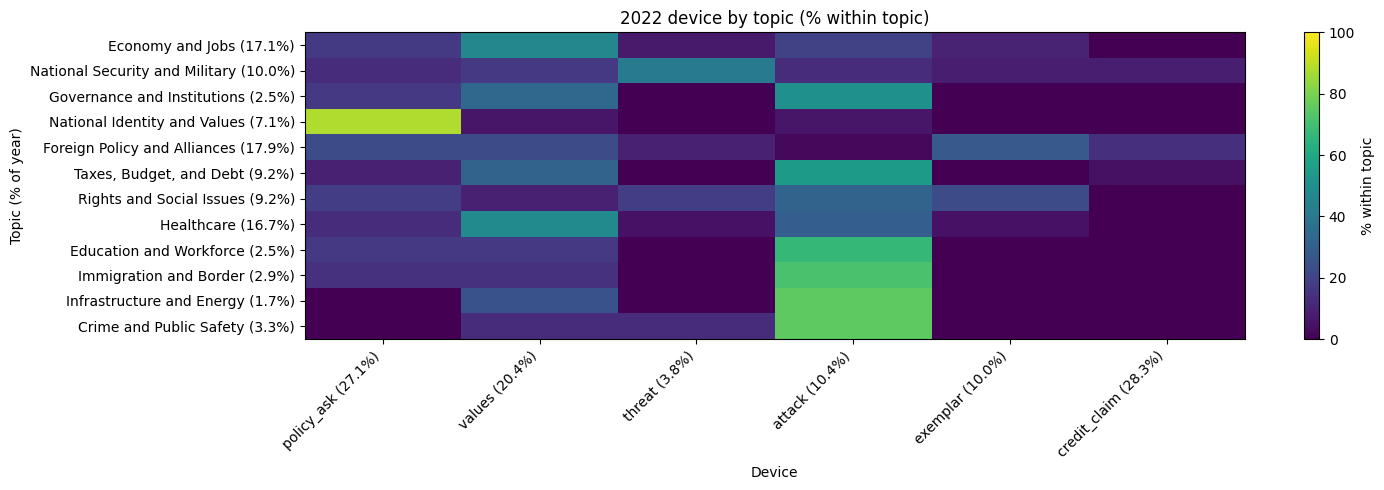

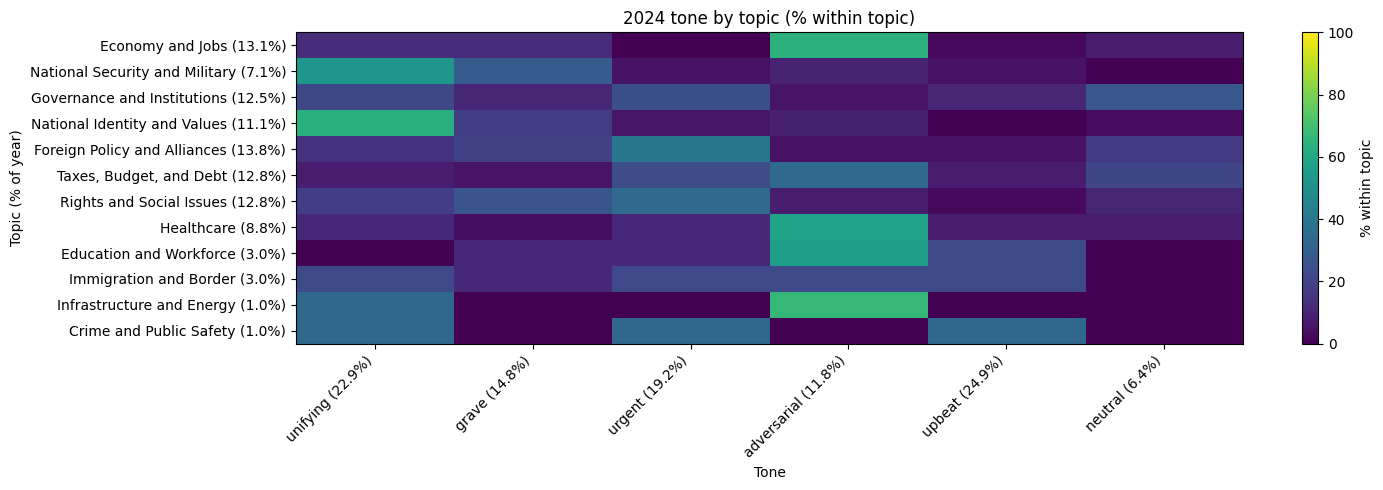

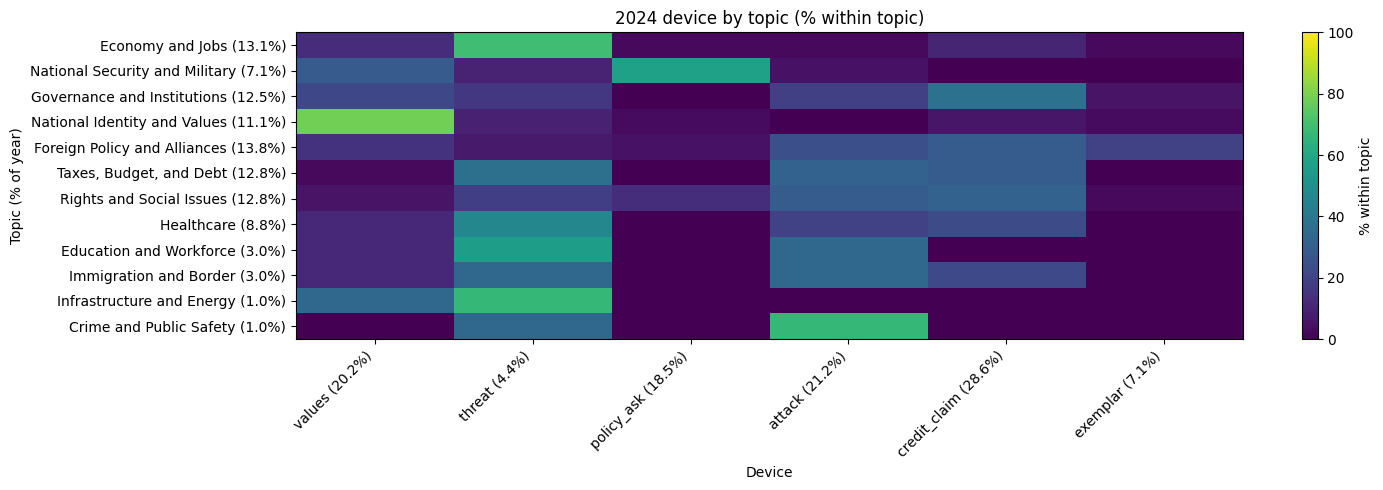

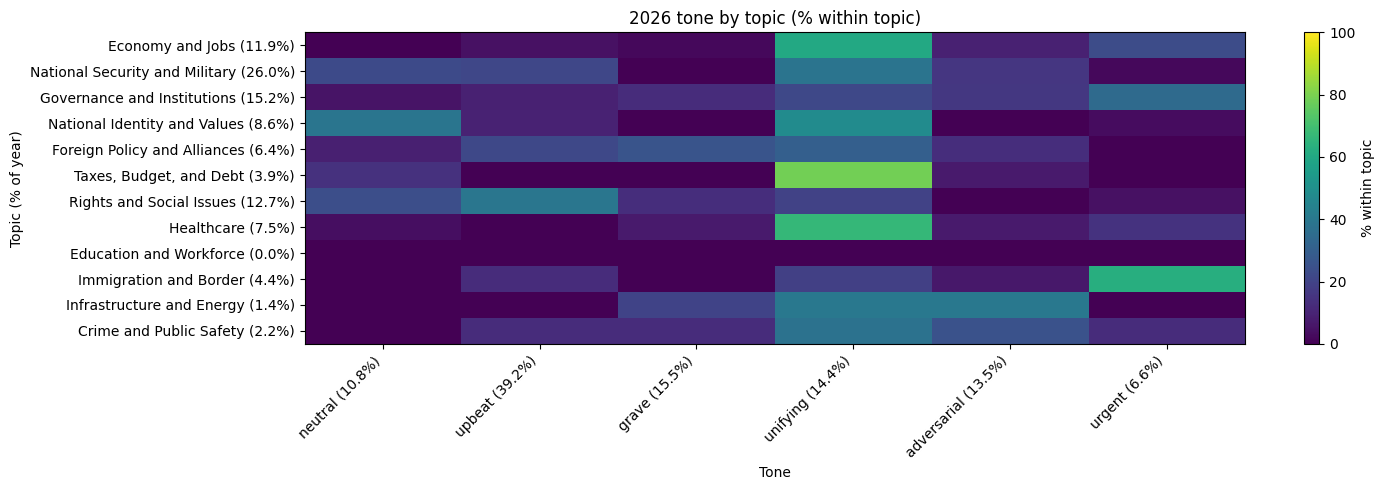

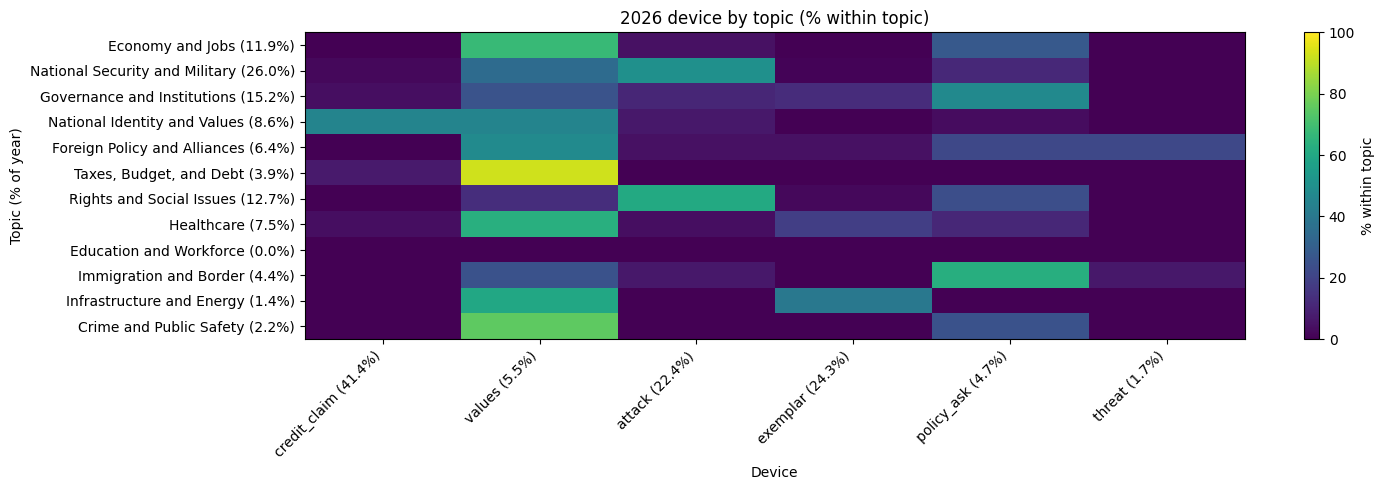

In [17]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

tones = (
    df2['tone'].dropna()
      .unique()
      .tolist()
)

devices = (
        df2['device'].dropna()
            .unique()
            .tolist()
)

topic_label_order = (
    df2["topic_label"]
      .value_counts()
      .index
      .tolist()
)
topic_label_order.sort()

macro_topic_order = (
    df2["macro_topic"]
      .value_counts()
      .index
    .tolist()
)
macro_topic_order

def topic_heatmap(data, year: int, topic="macro_topic", subgroup="device"):
    if subgroup not in {"tone", "device"}:
        raise ValueError("subgroup must be 'tone' or 'device'")
    elif subgroup == "tone":
        items = tones
    else:
        items = devices
    if topic not in {"macro_topic", "topic_label"}:
        raise ValueError("topic must be 'macro_topic' or 'topic_label'")
    elif topic == "macro_topic":
        topic_order = macro_topic_order
    else:
        topic_order = topic_label_order
    sub = data[(data["year"] == year) & data[subgroup].notna()].copy()
    counts = (
        sub.groupby([topic, subgroup])
           .size()
           .unstack(fill_value=0)
           .reindex(index=topic_order, columns=items, fill_value=0)
    )

    totals = counts.sum(axis=1).replace(0, np.nan)
    pct = (counts.div(totals, axis=0) * 100.0).fillna(0.0)

    # y labels show topic share within the year (% of chunks in that year)
    topic_share = (sub[topic].value_counts(normalize=True) * 100).reindex(topic_order).fillna(0.0)
    yticklabels = [f"{t} ({topic_share[t]:.1f}%)" for t in topic_order]

    subgroup_share = (sub[subgroup].value_counts(normalize=True) * 100).reindex(getattr(sub, subgroup).unique()).fillna(0.0)
    xticklabels = [f"{t} ({subgroup_share[t]:.1f}%)" for t in getattr(sub, subgroup).unique()]

    fig, ax = plt.subplots(figsize=(15, max(5, 0.35 * len(topic_order))))
    im = ax.imshow(pct.values, aspect="auto", vmin=0, vmax=100)

    ax.set_title(f"{year} {subgroup} by topic (% within topic)")
    ax.set_xlabel(subgroup.title())
    ax.set_ylabel("Topic (% of year)")
    ax.set_xticks(range(len(items)))
    ax.set_xticklabels(xticklabels, rotation=45, ha="right")
    ax.set_yticks(range(len(topic_order)))
    ax.set_yticklabels(yticklabels)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("% within topic")
    plt.tight_layout()
    plt.show()

for y in sorted(df2["year"].unique()):
    topic_heatmap(df2, y, subgroup="tone")
    topic_heatmap(df2, y, subgroup="device")


In [18]:
pd.options.display.max_rows = 200
#sub = data[(data["year"] == year) & data["device"].notna()].copy()
df2.groupby(by=["macro_topic","year"])["device"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=devices, fill_value=0).add_suffix("_device").merge(
    df2.groupby(by=["macro_topic","year"])["tone"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=tones, fill_value=0).add_suffix("_tone"),
    left_index=True,
    right_index=True
)

values_device  credit_claim_device  \
macro_topic                    year                                       
Crime and Public Safety        2012       0.250000             0.000000   
                               2014       0.000000             0.000000   
                               2016       0.000000             0.500000   
                               2020       0.000000             0.444444   
                               2022       0.000000             0.125000   
                               2024       0.000000             0.333333   
                               2026       0.000000             0.750000   
Economy and Jobs               2010       0.414634             0.317073   
                               2012       0.214286             0.321429   
                               2014       0.285714             0.357143   
                               2016       0.461538             0.269231   
                               2018       0.058824             0.529412   
                               2020       0.000000             0.806452   
                               2022       0.170732             0.463415   
                               2024       0.128205             0.692308   
                               2026       0.000000             0.674419   
Education and Workforce        2010       0.125000             0.000000   
                               2012       0.285714             0.142857   
                               2014       0.277778             0.222222   
                               2016       0.375000             0.250000   
                               2020       0.166667             0.166667   
                               2022       0.166667             0.166667   
                               2024       0.111111             0.555556   
Foreign Policy and Alliances   2010       0.461538             0.153846   
                               2012       0.416667             0.416667   
                               2014       0.437500             0.187500   
                               2016       0.217391             0.304348   
                               2018       0.111111             0.111111   
                               2020       0.176471             0.470588   
                               2022       0.232558             0.232558   
                               2024       0.146341             0.073171   
                               2026       0.000000             0.478261   
Governance and Institutions    2010       0.568182             0.022727   
                               2012       0.294118             0.176471   
                               2014       0.133333             0.066667   
                               2016       0.735294             0.029412   
                               2018       0.000000             0.000000   
                               2020       0.000000             0.000000   
                               2022       0.166667             0.333333   
                               2024       0.216216             0.162162   
                               2026       0.036364             0.254545   
Healthcare                     2010       0.125000             0.312500   
                               2012       0.000000             0.500000   
                               2014       0.000000             0.416667   
                               2016       0.312500             0.375000   
                               2018       0.125000             0.375000   
                               2020       0.000000             0.600000   
                               2022       0.125000             0.475000   
                               2024       0.115385             0.461538   
                               2026       0.037037             0.629630   
Immigration and Border         2010       0.000000             0.000000   
                               2012       0.000000            

In [19]:
df2.groupby(by="year")["tone"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=tones, fill_value=0)

tone,unifying,grave,urgent,upbeat,neutral,adversarial
year,,,,,,
2010,0.311321,0.169811,0.198113,0.179245,0.094340,0.047170
2012,0.293839,0.080569,0.265403,0.222749,0.099526,0.037915
2014,0.358382,0.075145,0.213873,0.265896,0.075145,0.011561
2016,0.431818,0.136364,0.181818,0.153409,0.062500,0.034091
2018,0.358491,0.132075,0.213836,0.276730,0.012579,0.006289
2020,0.247423,0.108247,0.103093,0.422680,0.072165,0.046392
2022,0.287500,0.141667,0.250000,0.258333,0.050000,0.012500
2024,0.228956,0.148148,0.191919,0.249158,0.063973,0.117845
2026,0.143646,0.154696,0.066298,0.392265,0.107735,0.135359


In [20]:
df2.groupby(by="year")["macro_topic"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=macro_topic_order, fill_value=0)

macro_topic,Economy and Jobs,National Security and Military,Governance and Institutions,National Identity and Values,Foreign Policy and Alliances,"Taxes, Budget, and Debt",Rights and Social Issues,Healthcare,Education and Workforce,Immigration and Border,Infrastructure and Energy,Crime and Public Safety
year,,,,,,,,,,,,
2010,0.193396,0.056604,0.207547,0.113208,0.061321,0.183962,0.023585,0.075472,0.037736,0.004717,0.042453,0.000000
2012,0.265403,0.104265,0.080569,0.037915,0.056872,0.142180,0.023697,0.018957,0.099526,0.023697,0.109005,0.037915
2014,0.161850,0.144509,0.086705,0.086705,0.092486,0.098266,0.069364,0.069364,0.104046,0.023121,0.057803,0.005780
2016,0.147727,0.107955,0.193182,0.125000,0.130682,0.062500,0.011364,0.090909,0.045455,0.017045,0.056818,0.011364
2018,0.106918,0.257862,0.018868,0.213836,0.056604,0.056604,0.132075,0.050314,0.000000,0.100629,0.006289,0.000000
2020,0.159794,0.231959,0.010309,0.118557,0.087629,0.020619,0.154639,0.103093,0.030928,0.030928,0.005155,0.046392
2022,0.169421,0.099174,0.024793,0.070248,0.177686,0.090909,0.090909,0.173554,0.024793,0.028926,0.016529,0.033058
2024,0.130872,0.073826,0.124161,0.110738,0.137584,0.127517,0.127517,0.087248,0.030201,0.030201,0.010067,0.010067
2026,0.118785,0.259669,0.151934,0.085635,0.063536,0.038674,0.127072,0.074586,0.000000,0.044199,0.013812,0.022099


In [21]:
df2.groupby(by="year")["device"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=devices, fill_value=0)

device,values,credit_claim,exemplar,policy_ask,attack,threat
year,,,,,,
2010,0.382075,0.245283,0.047170,0.207547,0.089623,0.028302
2012,0.246445,0.255924,0.047393,0.303318,0.127962,0.018957
2014,0.265896,0.202312,0.138728,0.346821,0.028902,0.017341
2016,0.505682,0.159091,0.034091,0.142045,0.090909,0.068182
2018,0.220126,0.194969,0.283019,0.182390,0.062893,0.056604
2020,0.144330,0.381443,0.247423,0.103093,0.118557,0.005155
2022,0.204167,0.283333,0.100000,0.270833,0.104167,0.037500
2024,0.202020,0.286195,0.070707,0.185185,0.212121,0.043771
2026,0.055249,0.414365,0.243094,0.046961,0.223757,0.016575


In [22]:
df2.head()

,year,chunk_id,chunk_index,uses_guest_example,guest_count,topic_id,tone,device,target,confidence,evidence,model,n_clauses,device_mix,tone_mix,error,topic_label,macro_topic,subtopic,macro_confidence
0,2010,2010_0000,0,False,0,0,unifying,values,the_public,high,"{'device': 'Our Constitution declares that from time to time, the President shall give to Congress information about the state of our Union.', 'target': 'fellow Americans', 'tone': 'unifying'}",mistral:latest,1,{'values': 1},{'unifying': 1},NaN,Military Appreciation,National Security and Military,Military Appreciation,high
1,2010,2010_0001,1,False,0,22,grave,values,the_public,high,"{'device': 'assume that our progress was inevitable, that America was always destined to succeed', 'target': 'the American people', 'tone': 'war and depression, great strife and great struggle'}",mistral:latest,1,{'values': 1},{'grave': 1},NaN,National Optimism,National Identity and Values,national optimism,high
2,2010,2010_0002,2,False,0,22,grave,values,the_public,high,"{'device': 'These were the times that tested the courage of our convictions and the strength of our Union.', 'target': 'the American people', 'tone': 'grave'}",mistral:latest,1,{'values': 1},{'grave': 1},NaN,National Optimism,National Identity and Values,national optimism,high
3,2010,2010_0003,3,False,0,22,unifying,values,the_public,high,"{'device': 'These were the times that tested the courage of our convictions and the strength of our Union.', 'target': 'America prevailed because we chose to move forward as one Nation, as one people.', 'tone': 'Again, we are tested.'}",mistral:latest,1,{'values': 1},{'unifying': 1},NaN,National Optimism,National Identity and Values,national optimism,high
4,2010,2010_0004,4,False,0,9,urgent,values,the_public,high,"{'device': 'we are tested. And again, we must answer history's call.', 'target': 'the American people', 'tone': 'Again, we are tested.'}",mistral:latest,1,{'values': 1},{'urgent': 1},NaN,American Rescue Plan,Economy and Jobs,American Rescue Plan,high


In [23]:
df2.groupby(by=['year','topic_label']).count()[['chunk_index']].pivot_table(index='topic_label', columns='year', values='chunk_index', fill_value=0)

year,2010,2012,2014,2016,2018,2020,2022,2024,2026
topic_label,,,,,,,,,
American Jobs,8.0,18.0,8.0,8.0,5.0,8.0,11.0,5.0,3.0
American Rescue Plan,15.0,13.0,0.0,1.0,0.0,3.0,5.0,8.0,19.0
Budget Cuts,33.0,14.0,8.0,2.0,1.0,0.0,8.0,19.0,8.0
Clean Energy,9.0,23.0,10.0,10.0,1.0,1.0,4.0,3.0,5.0
Counterterrorism Efforts,7.0,9.0,10.0,14.0,9.0,5.0,1.0,0.0,2.0
Democratic Process,19.0,2.0,2.0,22.0,0.0,0.0,0.0,9.0,10.0
Drug Pricing,0.0,0.0,0.0,0.0,2.0,4.0,6.0,14.0,19.0
Earmark Reform,23.0,13.0,13.0,7.0,3.0,1.0,4.0,11.0,14.0
Fundamental Rights,5.0,3.0,2.0,2.0,4.0,7.0,16.0,24.0,2.0
